# 02-The Catalyst Optimizer & Execution Plans

In Lesson 01, we established the physical architecture of a distributed cluster: Drivers, Executors, and Partitions. We proved that Spark mathematically fractures data across multiple JVMs to achieve parallel compute.

However, writing PySpark code (the DataFrame API or SQL) does **not** directly instruct the Executors what to do. PySpark is a purely declarative API. When you write a `join()` followed by a `filter()`, Spark does not blindly execute your commands in that order.

Between your Python script and the physical JVM clusters lies a sophisticated mathematical compiler known as the **Catalyst Optimizer**. Catalyst translates your declarative Python code into a Relational Algebra tree, applies hundreds of optimization algorithms (like Predicate Pushdown and Column Pruning), and generates the most efficient **Physical Execution Plan** possible.

If you cannot read the execution plan, you cannot engineer Big Data. Let's set up our environment to expose the matrix.

In [1]:
# Required installations: pip install pyspark matplotlib seaborn
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Catalyst Optimization Environment Ready.")

✅ Systems Architecture & Catalyst Optimization Environment Ready.


# 1. The Mathematics of Relational Tree Optimization

At its core, the Catalyst Optimizer is a functional tree-manipulation engine written in Scala. It treats your PySpark DataFrame transformations as an Abstract Syntax Tree (AST) $T$.

Optimization is the process of applying a set of transformation rules $\mathcal{R}$ to the tree until it reaches a fixed, mathematically minimal point $T_{opt}$:


$$T_{opt} = \mathcal{R}_n(\dots \mathcal{R}_2(\mathcal{R}_1(T)))$$

### The Two Laws of Optimizer Physics:

1. **Predicate Pushdown ($\sigma$)**: In relational algebra, a selection/filter ($\sigma$) should occur as early as possible. If your Python code explicitly joins a billion-row table and *then* filters for `country = 'US'`, Catalyst mathematically commutes the operations: $\sigma_{country='US'}(A \bowtie B) \rightarrow \sigma_{country='US'}(A) \bowtie B$. It filters the raw Parquet file *before* the network shuffle.
2. **Column Pruning ($\pi$)**: If a table has 500 columns, but your final `.select()` only requires 3, Catalyst pushes the projection ($\pi$) down to the storage layer, physically ignoring 497 columns during the disk read.


# 2. Architecting the Unoptimized Query

Let's boot a Spark cluster and intentionally write mathematically terrible, highly unoptimized Python code. We will join two tables blindly and then apply filters *after* the join.

We will then invoke `.explain(extended=True)` to watch the Catalyst Optimizer intercept our bad code, rewrite it, and generate a hyper-efficient physical plan.

In [2]:
# --- ⚙️ STEP 1: Booting the Distributed Engine ---
spark = SparkSession.builder \
    .appName("Catalyst_Physics") \
    .master("local[*]") \
    .getOrCreate()

# --- 📦 STEP 2: Creating Virtual Datasets ---
# Table A: Transactions (Massive Fact Table)
txns_data = [(1, 99, 250.0), (2, 42, 10.5), (3, 99, 1500.0), (4, 77, 85.0)]
txns_df = spark.createDataFrame(txns_data, ["txn_id", "user_id", "amount"])

# Table B: Users (Dimension Table)
users_data = [(99, "Aris", "TR"), (42, "Bob", "US"), (77, "Charlie", "UK")]
users_df = spark.createDataFrame(users_data, ["user_id", "name", "country"])

# --- 🛑 STEP 3: The "Bad" Declarative Python Code ---
print("--- 🚀 Executing Declarative PySpark Code ---")

# We intentionally join the full tables FIRST (mathematically expensive)
joined_df = txns_df.join(users_df, "user_id")

# We intentionally filter SECOND (acting on an unnecessarily bloated join result)
filtered_df = joined_df.filter(F.col("country") == "TR").filter(F.col("amount") > 100)

# We intentionally select our columns LAST
final_df = filtered_df.select("name", "amount")

print("✅ DataFrames linked in Python. Note: NO computation has occurred yet (Lazy Evaluation).")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/25 15:00:05 WARN Utils: Your hostname, Muhammet, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/06/25 15:00:05 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/25 15:00:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/25 15:00:06 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


--- 🚀 Executing Declarative PySpark Code ---
✅ DataFrames linked in Python. Note: NO computation has occurred yet (Lazy Evaluation).


# 3. Reading the Matrix (The Execution Plan)

Because of **Lazy Evaluation**, Spark has not processed a single byte of data yet. It has simply built an Unresolved Logical Plan.

To view how Catalyst intends to execute this, we call `.explain(extended=True)`. This reveals the 4 phases of Catalyst compilation.

In [3]:
# --- 🧠 STEP 4: Exposing the Catalyst Optimizer Logs ---
print("\n--- 🧠 Catalyst Optimizer: Execution Plan Matrix ---")

# This command asks the JVM to return the physical compilation states
final_df.explain(extended=True)

print("\n--- 💡 Engineering Insight into the Plan ---")
print("If you read the output above, you will see 4 distinct phases:")
print("1. == Parsed Logical Plan ==: This is a 1:1 translation of our bad Python code. Join first, Filter second.")
print("2. == Analyzed Logical Plan ==: Spark connects to the Catalog, verifying that 'user_id' actually exists and resolving data types (Integers/Strings).")
print("3. == Optimized Logical Plan ==: THE MAGIC. Notice the 'Filter' nodes. Catalyst mathematically moved 'Filter (country = TR)' to execute BEFORE the Join. It also injected 'Filter (isnotnull(user_id))' autonomously to drop nulls before shuffling.")
print("4. == Physical Plan ==: Spark translates the optimized logic into exact Java/C++ execution algorithms. It chose a 'SortMergeJoin' or 'BroadcastHashJoin' and decided exactly how to partition the data across the Executors.")


--- 🧠 Catalyst Optimizer: Execution Plan Matrix ---
== Parsed Logical Plan ==
'Project ['name, 'amount]
+- Filter (amount#2 > cast(100 as double))
   +- Filter (country#5 = TR)
      +- Project [user_id#1L, txn_id#0L, amount#2, name#4, country#5]
         +- Join Inner, (user_id#1L = user_id#3L)
            :- LogicalRDD [txn_id#0L, user_id#1L, amount#2], false
            +- LogicalRDD [user_id#3L, name#4, country#5], false

== Analyzed Logical Plan ==
name: string, amount: double
Project [name#4, amount#2]
+- Filter (amount#2 > cast(100 as double))
   +- Filter (country#5 = TR)
      +- Project [user_id#1L, txn_id#0L, amount#2, name#4, country#5]
         +- Join Inner, (user_id#1L = user_id#3L)
            :- LogicalRDD [txn_id#0L, user_id#1L, amount#2], false
            +- LogicalRDD [user_id#3L, name#4, country#5], false

== Optimized Logical Plan ==
Project [name#4, amount#2]
+- Join Inner, (user_id#1L = user_id#3L)
   :- Project [user_id#1L, amount#2]
   :  +- Filter ((isnotnu

# 4. Visualizing the Catalyst Compilation Topography

To fully grasp the bridge between your Python script and the JVM hardware, let's map the topological transformation of the graph.

/tmp/ipykernel_5637/2972221145.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0, 0), 3.5, 7.5, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_5637/2972221145.py:11: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((4.25, 0), 3.5, 7.5, fill=True, color='#f1c40f', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_5637/2972221145.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((8.5, 0), 3.5, 7.5, fill=True, color='#3498db', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--'))


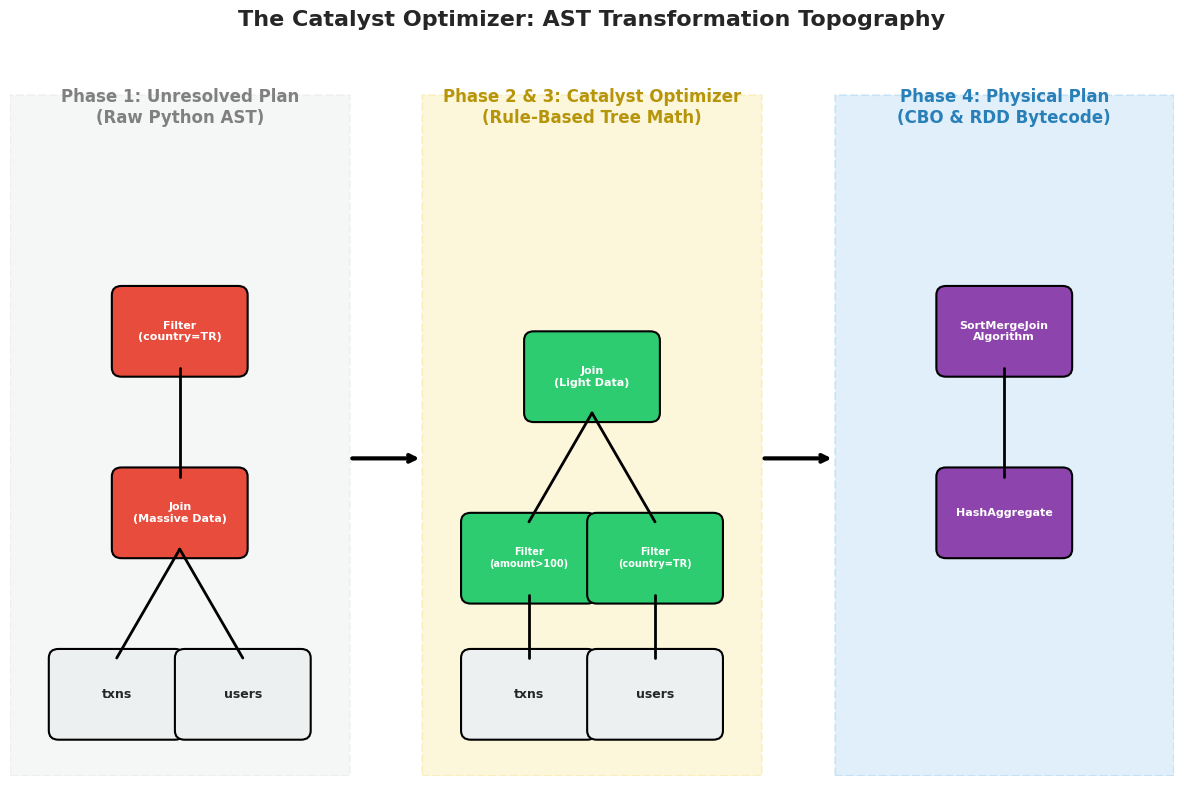

In [4]:
# Visualizing the Catalyst Optimizer Architecture
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle("The Catalyst Optimizer: AST Transformation Topography", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Background Zones
ax.add_patch(patches.Rectangle((0, 0), 3.5, 7.5, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(1.75, 7.2, "Phase 1: Unresolved Plan\n(Raw Python AST)", ha='center', color='gray', fontweight='bold')

ax.add_patch(patches.Rectangle((4.25, 0), 3.5, 7.5, fill=True, color='#f1c40f', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(6, 7.2, "Phase 2 & 3: Catalyst Optimizer\n(Rule-Based Tree Math)", ha='center', color='#b7950b', fontweight='bold')

ax.add_patch(patches.Rectangle((8.5, 0), 3.5, 7.5, fill=True, color='#3498db', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(10.25, 7.2, "Phase 4: Physical Plan\n(CBO & RDD Bytecode)", ha='center', color='#2980b9', fontweight='bold')

# 2. Draw The Unresolved Tree (Our "Bad" Code)
# Base Tables
ax.add_patch(patches.FancyBboxPatch((0.5, 0.5), 1.2, 0.8, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#ecf0f1'))
ax.text(1.1, 0.9, "txns", ha='center', va='center', fontweight='bold', fontsize=9)

ax.add_patch(patches.FancyBboxPatch((1.8, 0.5), 1.2, 0.8, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#ecf0f1'))
ax.text(2.4, 0.9, "users", ha='center', va='center', fontweight='bold', fontsize=9)

# Join Node
ax.add_patch(patches.FancyBboxPatch((1.15, 2.5), 1.2, 0.8, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#e74c3c'))
ax.text(1.75, 2.9, "Join\n(Massive Data)", ha='center', va='center', color='white', fontweight='bold', fontsize=8)

# Filter Node
ax.add_patch(patches.FancyBboxPatch((1.15, 4.5), 1.2, 0.8, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#e74c3c'))
ax.text(1.75, 4.9, "Filter\n(country=TR)", ha='center', va='center', color='white', fontweight='bold', fontsize=8)

# Tree Edges
ax.plot([1.1, 1.75], [1.3, 2.5], color='black', lw=2)
ax.plot([2.4, 1.75], [1.3, 2.5], color='black', lw=2)
ax.plot([1.75, 1.75], [3.3, 4.5], color='black', lw=2)


# 3. Draw The Optimized Tree (The Catalyst Rewrite)
# Base Tables
ax.add_patch(patches.FancyBboxPatch((4.75, 0.5), 1.2, 0.8, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#ecf0f1'))
ax.text(5.35, 0.9, "txns", ha='center', va='center', fontweight='bold', fontsize=9)

ax.add_patch(patches.FancyBboxPatch((6.05, 0.5), 1.2, 0.8, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#ecf0f1'))
ax.text(6.65, 0.9, "users", ha='center', va='center', fontweight='bold', fontsize=9)

# Predicate Pushdown Nodes (Filters moved DOWN)
ax.add_patch(patches.FancyBboxPatch((4.75, 2.0), 1.2, 0.8, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#2ecc71'))
ax.text(5.35, 2.4, "Filter\n(amount>100)", ha='center', va='center', color='white', fontweight='bold', fontsize=7)

ax.add_patch(patches.FancyBboxPatch((6.05, 2.0), 1.2, 0.8, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#2ecc71'))
ax.text(6.65, 2.4, "Filter\n(country=TR)", ha='center', va='center', color='white', fontweight='bold', fontsize=7)

# Optimized Join Node
ax.add_patch(patches.FancyBboxPatch((5.4, 4.0), 1.2, 0.8, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#2ecc71'))
ax.text(6.0, 4.4, "Join\n(Light Data)", ha='center', va='center', color='white', fontweight='bold', fontsize=8)

# Tree Edges
ax.plot([5.35, 5.35], [1.3, 2.0], color='black', lw=2)
ax.plot([6.65, 6.65], [1.3, 2.0], color='black', lw=2)
ax.plot([5.35, 6.0], [2.8, 4.0], color='black', lw=2)
ax.plot([6.65, 6.0], [2.8, 4.0], color='black', lw=2)


# 4. Draw the Physical Plan Nodes (Hardware Algorithms)
ax.add_patch(patches.FancyBboxPatch((9.65, 2.5), 1.2, 0.8, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#8e44ad'))
ax.text(10.25, 2.9, "HashAggregate", ha='center', va='center', color='white', fontweight='bold', fontsize=8)

ax.add_patch(patches.FancyBboxPatch((9.65, 4.5), 1.2, 0.8, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#8e44ad'))
ax.text(10.25, 4.9, "SortMergeJoin\nAlgorithm", ha='center', va='center', color='white', fontweight='bold', fontsize=8)

ax.plot([10.25, 10.25], [3.3, 4.5], color='black', lw=2)

# Flow Arrows
ax.annotate("", xy=(4.25, 3.5), xytext=(3.5, 3.5), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
ax.annotate("", xy=(8.5, 3.5), xytext=(7.75, 3.5), arrowprops=dict(arrowstyle="->", lw=3, color="black"))

plt.xlim(0, 12)
plt.ylim(0, 8)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the Catalyst Optimizer like **A Google Maps GPS Navigator vs. A Printed Map**:

* **Unoptimized Code (The Printed Map)**: You print directions to drive from New York to Los Angeles. Your initial plan (your declarative Python code) says: *"Drive on I-80 West for 2,000 miles."* If there is a massive bridge collapse in Ohio, your printed map does not know. You will drive 500 miles, hit the broken bridge, and fail.
* **The Catalyst Optimizer (Google Maps)**: You enter the destination into your GPS. Before you even turn on the engine (Lazy Evaluation), the GPS looks at your route (The Unresolved Logical Plan). It connects to satellite traffic servers (The Catalog/Analyzer) and realizes the bridge in Ohio is destroyed. The GPS automatically rewrites your route (The Optimized Logical Plan) to bypass Ohio entirely. Finally, it looks at what kind of car you are driving to calculate exactly how much gas you need for the new route (The Physical Execution Plan).

By utilizing the Catalyst Optimizer, PySpark mathematically guarantees that even junior data engineers who write poorly ordered DataFrame operations will have their code securely rewritten into highly performant, distributed C++/JVM bytecode.